In [19]:
import pandas as pd          # For uploading/loading the data
import numpy as np           # Numerical operations
import re                    # Data cleaning
import nltk                  # NLP library
import matplotlib.pyplot as plt  # Data visualization

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter
from wordcloud import WordCloud

# Download required NLTK files
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [20]:
data = {
    "Review": [
        "The product quality is excellent and delivery was very fast.",
        "Very bad packaging and the item was damaged.",
        "Customer service was helpful and responsive.",
        "The delivery was delayed and support team did not respond.",
        "Amazing product. Worth the money.",
        "Poor quality product and terrible experience.",
        "Fast shipping and good packaging.",
        "The product stopped working after two days.",
        "Excellent service and great quality.",
        "Late delivery and bad customer support."
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

In [21]:
print("Customer Reviews Dataset")
print(df.head())

Customer Reviews Dataset
                                              Review
0  The product quality is excellent and delivery ...
1       Very bad packaging and the item was damaged.
2       Customer service was helpful and responsive.
3  The delivery was delayed and support team did ...
4                  Amazing product. Worth the money.


In [22]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
  text = text.lower()

  text = re.sub(r'[^a-zA-Z\s]', '', text)

  words = word_tokenize(text)

  words = [word for word in words if word not in stop_words]

  cleaned_text = " ".join(words)
  return cleaned_text

df['Cleaned_Review'] = df['Review'].apply(clean_text)

print("Cleaned Customer Reviews Dataset")
print(df[['Review', 'Cleaned_Review']])

Cleaned Customer Reviews Dataset
                                              Review  \
0  The product quality is excellent and delivery ...   
1       Very bad packaging and the item was damaged.   
2       Customer service was helpful and responsive.   
3  The delivery was delayed and support team did ...   
4                  Amazing product. Worth the money.   
5      Poor quality product and terrible experience.   
6                  Fast shipping and good packaging.   
7        The product stopped working after two days.   
8               Excellent service and great quality.   
9            Late delivery and bad customer support.   

                             Cleaned_Review  
0   product quality excellent delivery fast  
1                bad packaging item damaged  
2       customer service helpful responsive  
3     delivery delayed support team respond  
4               amazing product worth money  
5  poor quality product terrible experience  
6              fast shipping

In [23]:
sia = SentimentIntensityAnalyzer()
def analyze_sentiment(review):
  score = sia.polarity_scores(review)
  compound = score['compound']
  if compound >= 0.05:
    return "Positive"
  elif compound <= 0.05:
    return "Negative"
  else:
    return "Neutral"

df['Sentiment'] = df['Cleaned_Review'].apply(analyze_sentiment)

print("Customer Reviews Dataset with Sentiment Analysis")
print(df[['Review', 'Sentiment']])

Customer Reviews Dataset with Sentiment Analysis
                                              Review Sentiment
0  The product quality is excellent and delivery ...  Positive
1       Very bad packaging and the item was damaged.  Negative
2       Customer service was helpful and responsive.  Positive
3  The delivery was delayed and support team did ...  Positive
4                  Amazing product. Worth the money.  Positive
5      Poor quality product and terrible experience.  Negative
6                  Fast shipping and good packaging.  Positive
7        The product stopped working after two days.  Negative
8               Excellent service and great quality.  Positive
9            Late delivery and bad customer support.  Negative


In [24]:
all_words = " ".join(df['Cleaned_Review'])
word_list = all_words.split()
word_freq = Counter(word_list)
print("Top 10 Common Keywords")
print(word_freq.most_common(10))

Top 10 Common Keywords
[('product', 4), ('quality', 3), ('delivery', 3), ('excellent', 2), ('fast', 2), ('bad', 2), ('packaging', 2), ('customer', 2), ('service', 2), ('support', 2)]


In [25]:
negative_reviews = df[df['Sentiment'] == 'Negative']
negative_words = " ".join(negative_reviews['Cleaned_Review'])
negative_word_list = negative_words.split()
complaint_freq = Counter(negative_word_list)
print("\nMost Common Complaint Keywords")
print(complaint_freq.most_common(10))


Most Common Complaint Keywords
[('bad', 2), ('product', 2), ('packaging', 1), ('item', 1), ('damaged', 1), ('poor', 1), ('quality', 1), ('terrible', 1), ('experience', 1), ('stopped', 1)]


In [26]:
sentiment_counts = df['Sentiment'].value_counts()
print("\nSentiment Distribution")
print(sentiment_counts)


Sentiment Distribution
Sentiment
Positive    6
Negative    4
Name: count, dtype: int64


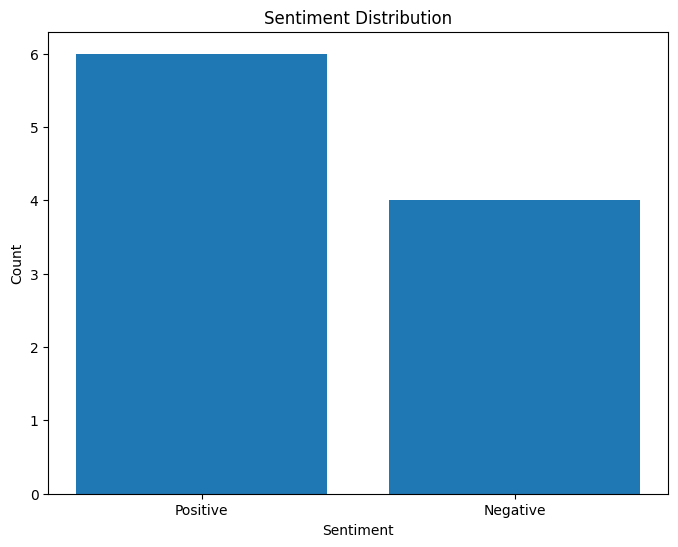

In [27]:
sentiment_counts = df['Sentiment'].value_counts()
plt.figure(figsize=(8, 6))
plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.title('Sentiment Distribution')
plt.show()

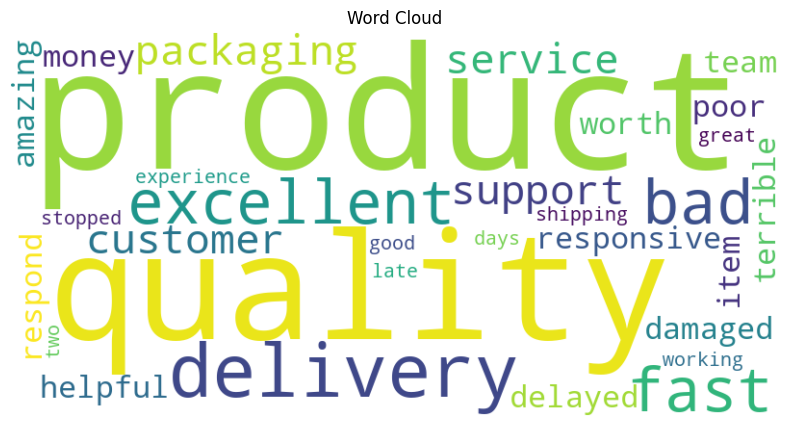

In [35]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
    ).generate(all_words)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud,interpolation='bilinear')

plt.axis("off")
plt.title("Word Cloud")

plt.show()

In [39]:
print("\nbusiness insights")
print("-------------------------------")

positive_count = len(df[df['Sentiment'] == 'Positive'])
negative_count = len(df[df['Sentiment'] == 'Negative'])

print("Total Positive Reviews:", positive_count)
print("Total Negative Reviews:", negative_count)

print("\ncommon positive area")
print(".product quality")
print(".fast delivery")
print(".good customer service")





business insights
-------------------------------
Total Positive Reviews: 6
Total Negative Reviews: 4

common positive area
.product quality
.fast delivery
.good customer service
